**Part A — Iterated Linear Models:**
Run AR(1), Kitchen Sink OLS, Lasso across multiple expanding windows.
Average the results to get stable, reliable Win Rate and R-squared numbers.

**Part B — CNN 4-Pool Architecture:**
- Pool 1: Squared features → Lasso (linear selection of non-linear features)
- Pool 2: Unsquared features → Lasso (linear selection of raw features)
- Pool 3: Squared features → CNN encoder (neural network learns patterns)
- Pool 4: Unsquared features → CNN encoder (neural network learns patterns)
- Pool 5: Combine all 4 pools → final prediction

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV, LogisticRegression, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers

tf.random.set_seed(42)
np.random.seed(42)

pd.set_option('display.max_columns', 100)
print('Libraries loaded.')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded.
TensorFlow version: 2.21.0


In [10]:
# Load all data sources (same as NB05)
consol = pd.read_csv('consolidated_db.csv', parse_dates=['trade_date'])
dam = pd.read_csv('uploads/da_model_dataset.csv', parse_dates=['date'])
eua = pd.read_csv('uploads/eua_front_year.csv', parse_dates=['trade_date'])

dam.rename(columns={'date': 'trade_date'}, inplace=True)
dam_cols = [c for c in dam.columns if c not in consol.columns and c != 'trade_date']

master = consol.merge(dam[['trade_date'] + dam_cols], on='trade_date', how='left')
master = master.merge(
    eua[['trade_date', 'volume', 'open_interest']].rename(
        columns={'volume': 'eua_volume', 'open_interest': 'eua_oi'}),
    on='trade_date', how='left'
)

print(f'Master dataset: {master.shape[0]} trading days x {master.shape[1]} columns')

Master dataset: 1310 trading days x 70 columns


In [11]:
# FEATURE ENGINEERING (replicate NB05)

# Linear features
energy_base = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent',
               'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']
dam_features = [c for c in dam_cols if c != 'lag_cot_date' and c != 'lag_r_EUA']
linear_candidates = list(dict.fromkeys(energy_base + dam_features))
linear_candidates = [c for c in linear_candidates if c in master.columns]

# Non-linear features
# Block 1: Energy NL (squared returns, ratios, spreads)
energy_nl = []
for col in ['lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        energy_nl.append(f'{col}_sq')

if all(c in master.columns for c in ['Coal', 'TTF']):
    master['lag_coal_gas_ratio'] = (master['Coal'] / master['TTF'].replace(0, np.nan)).shift(1)
    energy_nl.append('lag_coal_gas_ratio')

if all(c in master.columns for c in ['Power', 'TTF', 'Coal']):
    master['lag_spark_spread'] = (master['Power'] - master['TTF']).shift(1)
    master['lag_dark_spread'] = (master['Power'] - master['Coal']).shift(1)
    energy_nl.extend(['lag_spark_spread', 'lag_dark_spread'])

# Block 2: Auction NL
auction_nl = []
for col in ['lag_eu_auction_premium', 'lag_eu_cover_ffill_surp']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        auction_nl.append(f'{col}_sq')

# Block 3: COT NL
cot_nl = []
for col in ['lag_IF_net_z26', 'lag_CU_net_z26', 'lag_IF_concentration']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        cot_nl.append(f'{col}_sq')

if all(c in master.columns for c in ['lag_IF_net_z26', 'lag_CU_net_z26']):
    master['lag_spec_comm_imbalance'] = master['lag_IF_net_z26'] - master['lag_CU_net_z26']
    cot_nl.append('lag_spec_comm_imbalance')

if 'lag_IF_net_z26' in master.columns:
    master['lag_crowded_spec'] = (master['lag_IF_net_z26'].abs() > 1.5).astype(int)
    cot_nl.append('lag_crowded_spec')

# Block 4: Options NL
opts_nl = []
for col in ['lag_atm_iv', 'lag_rr_25', 'lag_vrp', 'lag_rv_ratio']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        opts_nl.append(f'{col}_sq')

if 'lag_atm_iv' in master.columns:
    iv_p75 = master['lag_atm_iv'].rolling(252, min_periods=60).quantile(0.75)
    master['lag_high_iv_regime'] = (master['lag_atm_iv'] > iv_p75).astype(int)
    opts_nl.append('lag_high_iv_regime')

# Block 5: Cross-block interactions
cross_nl = []
for a, b, name in [
    ('lag_r_TTF', 'lag_IF_net_z26', 'lag_TTF_x_IF_z26'),
    ('lag_r_TTF', 'lag_atm_iv', 'lag_TTF_x_IV'),
    ('lag_r_Coal', 'lag_CU_net_z26', 'lag_Coal_x_CU_z26'),
    ('lag_eu_auction_premium', 'lag_IF_net_z26', 'lag_auc_x_IF'),
    ('lag_IF_net_z26', 'lag_atm_iv', 'lag_IF_x_IV'),
]:
    if all(c in master.columns for c in [a, b]):
        master[name] = master[a] * master[b]
        cross_nl.append(name)

all_nl_features = energy_nl + auction_nl + cot_nl + opts_nl + cross_nl
all_candidates = linear_candidates + all_nl_features

# Clean
for c in all_candidates:
    if c in master.columns:
        master[c] = master[c].replace([np.inf, -np.inf], np.nan)

# 70% coverage filter
target = 'r_EUA'
coverage = master[all_candidates].notna().mean()
all_candidates = [c for c in all_candidates if coverage[c] >= 0.70]

# Separate squared vs unsquared
squared_features = [c for c in all_candidates if '_sq' in c]
unsquared_features = [c for c in all_candidates if '_sq' not in c]

print(f'Total features after coverage filter: {len(all_candidates)}')
print(f'  Squared (non-linear): {len(squared_features)}')
print(f'  Unsquared (linear):   {len(unsquared_features)}')
print(f'\nSquared: {squared_features}')

# model matrix
model_data = master[[target, 'trade_date'] + all_candidates].dropna().reset_index(drop=True)
print(f'\nClean sample: {len(model_data)} trading days')
print(f'Date range: {model_data.trade_date.min().date()} to {model_data.trade_date.max().date()}')

Total features after coverage filter: 69
  Squared (non-linear): 13
  Unsquared (linear):   56

Squared: ['lag_r_TTF_sq', 'lag_r_Coal_sq', 'lag_r_Brent_sq', 'lag_r_Power_sq', 'lag_eu_auction_premium_sq', 'lag_eu_cover_ffill_surp_sq', 'lag_IF_net_z26_sq', 'lag_CU_net_z26_sq', 'lag_IF_concentration_sq', 'lag_atm_iv_sq', 'lag_rr_25_sq', 'lag_vrp_sq', 'lag_rv_ratio_sq']

Clean sample: 963 trading days
Date range: 2021-06-09 to 2026-02-25


## Part A: Iterated Linear Model Evaluation

In [12]:
# ITERATED EXPANDING WINDOW EVALUATION

y_all = model_data[target].values
X_all = model_data[all_candidates].values

min_train = 500     # minimum training window
test_window = 60    # test on 60 days each iteration
step_size = 40      # slide forward by 40 days

# iteration boundaries
iterations = []
for test_start in range(min_train, len(y_all) - test_window + 1, step_size):
    test_end = test_start + test_window
    iterations.append((test_start, test_end))

print(f'Number of iterations: {len(iterations)}')
print(f'Training sizes: {iterations[0][0]} to {iterations[-1][0]} days')
print(f'Test window: {test_window} days each')

# all models across all iterations
results = {'AR1': [], 'KitchenSink': [], 'Lasso': [], 'ElasticNet': []}
alphas = np.logspace(-6, -1, 30)

for i, (test_start, test_end) in enumerate(iterations):
    X_tr, y_tr = X_all[:test_start], y_all[:test_start]
    X_te, y_te = X_all[test_start:test_end], y_all[test_start:test_end]
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    ss_tot = np.sum((y_te - y_te.mean())**2)
    
    # AR(1)
    ar_idx = all_candidates.index('lag_r_EUA')
    m_ar = sm.OLS(y_tr, sm.add_constant(X_tr_s[:, ar_idx:ar_idx+1])).fit()
    p_ar = m_ar.predict(sm.add_constant(X_te_s[:, ar_idx:ar_idx+1]))
    results['AR1'].append({
        'wr': ((p_ar > 0) == (y_te > 0)).mean(),
        'r2': 1 - np.sum((y_te - p_ar)**2)/ss_tot if ss_tot > 0 else 0
    })
    
    # Kitchen Sink OLS
    try:
        m_ks = sm.OLS(y_tr, sm.add_constant(X_tr_s)).fit()
        p_ks = m_ks.predict(sm.add_constant(X_te_s))
        results['KitchenSink'].append({
            'wr': ((p_ks > 0) == (y_te > 0)).mean(),
            'r2': 1 - np.sum((y_te - p_ks)**2)/ss_tot if ss_tot > 0 else 0
        })
    except:
        results['KitchenSink'].append({'wr': np.nan, 'r2': np.nan})
    
    # Lasso CV
    tscv = TimeSeriesSplit(n_splits=3)
    lasso = LassoCV(alphas=alphas, cv=tscv, max_iter=20000, random_state=42)
    lasso.fit(X_tr_s, y_tr)
    p_l = lasso.predict(X_te_s)
    results['Lasso'].append({
        'wr': ((p_l > 0) == (y_te > 0)).mean(),
        'r2': 1 - np.sum((y_te - p_l)**2)/ss_tot if ss_tot > 0 else 0,
        'survivors': int((lasso.coef_ != 0).sum()),
        'alpha': lasso.alpha_
    })
    

# Summary
print('\n' + '='*70)
print('ITERATED LINEAR MODEL RESULTS')
print('='*70)
for name in ['AR1', 'KitchenSink', 'Lasso']:
    df = pd.DataFrame(results[name])
    wrs = df['wr'].dropna()
    r2s = df['r2'].dropna()
    print(f'{name:>15}: Avg WR = {wrs.mean():.2%} +/- {wrs.std():.2%}  |  Avg R2 = {r2s.mean():.4f}  |  [{wrs.min():.2%}, {wrs.max():.2%}]')
    if 'survivors' in df.columns:
        print(f'                 Avg survivors: {df["survivors"].mean():.1f}, zero-feature iters: {(df["survivors"]==0).sum()}/{len(df)}')

Number of iterations: 11
Training sizes: 500 to 900 days
Test window: 60 days each

ITERATED LINEAR MODEL RESULTS
            AR1: Avg WR = 48.64% +/- 4.82%  |  Avg R2 = -0.0192  |  [38.33%, 56.67%]
    KitchenSink: Avg WR = 51.67% +/- 3.12%  |  Avg R2 = -0.5362  |  [48.33%, 55.00%]
          Lasso: Avg WR = 47.12% +/- 5.87%  |  Avg R2 = -0.0092  |  [36.67%, 53.33%]
                 Avg survivors: 0.2, zero-feature iters: 10/11


In [13]:
print("Iter | Train |       Test Period        | AR(1)  | K.Sink | Lasso  | Lasso Ft ")
print("-" * 95)

all_ar, all_ks, all_l, all_e = [], [], [], []

for i, (test_start, test_end) in enumerate(iterations):
    X_tr, y_tr = X_all[:test_start], y_all[:test_start]
    X_te, y_te = X_all[test_start:test_end], y_all[test_start:test_end]
    d_start = str(model_data['trade_date'].iloc[test_start].date())
    d_end = str(model_data['trade_date'].iloc[test_end - 1].date())

    wr_ar = [r['wr'] for r in results['AR1']][i]
    wr_ks = [r['wr'] for r in results['KitchenSink']][i]
    wr_l = [r['wr'] for r in results['Lasso']][i]
    ns_l = [r['survivors'] for r in results['Lasso']][i]

    all_ar.append(wr_ar)
    all_ks.append(wr_ks)
    all_l.append(wr_l)

    print("  %2d | %4d  | %s to %s | %5.1f%% | %5.1f%% | %5.1f%% | %2d/69" % (
        i+1, test_start, d_start, d_end, wr_ar*100, wr_ks*100, wr_l*100, ns_l))

print("-" * 95)
print(" AVG |       |                          | %5.1f%% | %5.1f%% | %5.1f%% | %5.1f%%" % (
    np.mean(all_ar)*100, np.nanmean(all_ks)*100, np.mean(all_l)*100, np.mean(all_e)*100))
print(" STD |       |                          | %5.1f%% | %5.1f%% | %5.1f%% | %5.1f%%" % (
    np.std(all_ar)*100, np.nanstd(all_ks)*100, np.std(all_l)*100, np.std(all_e)*100))

Iter | Train |       Test Period        | AR(1)  | K.Sink | Lasso  | Lasso Ft 
-----------------------------------------------------------------------------------------------
   1 |  500  | 2023-07-04 to 2023-10-26 |  45.0% |   nan% |  51.7% |  0/69
   2 |  540  | 2023-09-20 to 2024-01-11 |  38.3% |  55.0% |  53.3% |  2/69
   3 |  580  | 2023-12-05 to 2024-05-15 |  51.7% |  48.3% |  53.3% |  0/69
   4 |  620  | 2024-03-22 to 2024-07-26 |  56.7% |  53.3% |  48.3% |  0/69
   5 |  660  | 2024-06-25 to 2024-10-04 |  51.7% |   nan% |  46.7% |  0/69
   6 |  700  | 2024-09-03 to 2024-12-13 |  45.0% |   nan% |  36.7% |  0/69
   7 |  740  | 2024-11-12 to 2025-02-27 |  46.7% |   nan% |  53.3% |  0/69
   8 |  780  | 2025-01-24 to 2025-05-28 |  51.7% |  48.3% |  43.3% |  0/69
   9 |  820  | 2025-04-23 to 2025-08-22 |  50.0% |   nan% |  48.3% |  0/69
  10 |  860  | 2025-07-03 to 2025-11-21 |  48.3% |   nan% |  45.0% |  0/69
  11 |  900  | 2025-10-21 to 2026-02-19 |  50.0% |  53.3% |  38.3% |  0/69


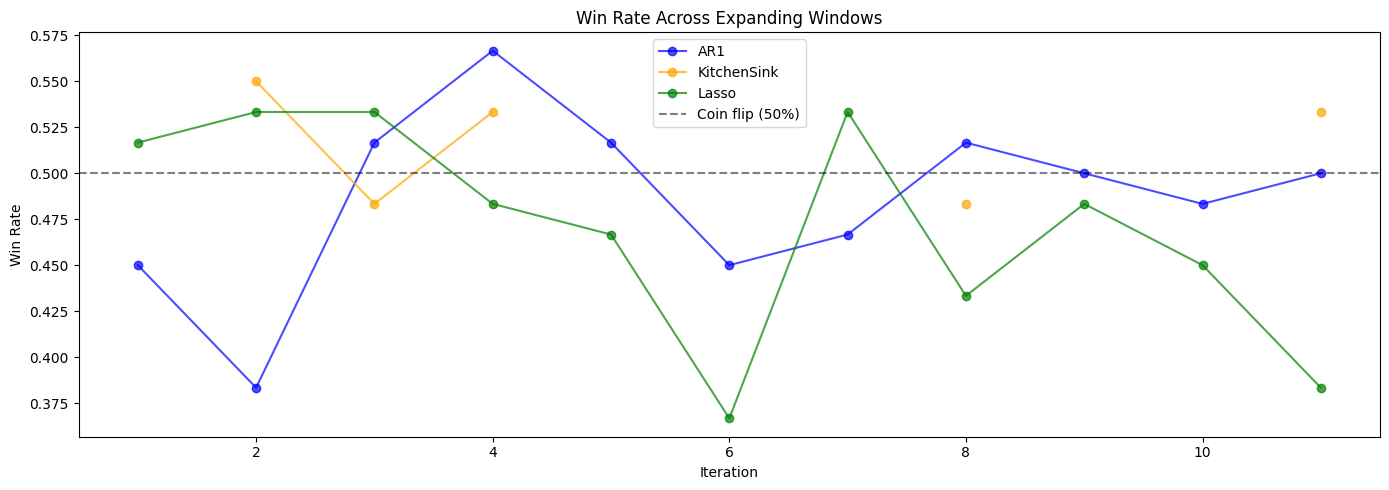

In [14]:
# Plot Win Rate across iterations
fig, axes = plt.subplots(figsize=(14, 5))

# WR over iterations
ax1 = axes
for name, color in [('AR1', 'blue'), ('KitchenSink', 'orange'), ('Lasso', 'green')]:
    wrs = [r['wr'] for r in results[name]]
    ax1.plot(range(1, len(wrs)+1), wrs, marker='o', label=name, color=color, alpha=0.7)
ax1.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Coin flip (50%)')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Win Rate')
ax1.set_title('Win Rate Across Expanding Windows')
ax1.legend()

plt.tight_layout()
plt.savefig('iterated_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Part B: CNN 4-Pool Architecture

### Architecture diagram:
```
Features ──┬── Squared (13 features) ──┬── Pool 1: Lasso ──────────────┐
           |                            |                                |
           |                            └── Pool 3: CNN encoder ────────┤
           |                                                             ├── Pool 5: Combined prediction
           └── Unsquared (56 features) ┬── Pool 2: Lasso ──────────────┤
                                        |                                |
                                        └── Pool 4: CNN encoder ────────┘
```

In [15]:
# DATA FOR 4-POOL ARCHITECTURE

# 80/20 chronological split
n = len(model_data)
split_idx = int(n * 0.80)
train_data = model_data.iloc[:split_idx]
test_data = model_data.iloc[split_idx:]

print(f'Train: {len(train_data)} days ({train_data.trade_date.min().date()} to {train_data.trade_date.max().date()})')
print(f'Test:  {len(test_data)} days ({test_data.trade_date.min().date()} to {test_data.trade_date.max().date()})')

# Separate and scale squared vs unsquared features
scaler_sq = StandardScaler()
scaler_unsq = StandardScaler()

X_sq_train = scaler_sq.fit_transform(train_data[squared_features].values)
X_sq_test = scaler_sq.transform(test_data[squared_features].values)

X_unsq_train = scaler_unsq.fit_transform(train_data[unsquared_features].values)
X_unsq_test = scaler_unsq.transform(test_data[unsquared_features].values)

y_train = train_data[target].values
y_test = test_data[target].values

# Binary direction labels
y_dir_train = (y_train > 0).astype(np.float32)
y_dir_test = (y_test > 0).astype(np.float32)

print(f'\nSquared features:   {X_sq_train.shape[1]} (input to Pools 1 & 3)')
print(f'Unsquared features: {X_unsq_train.shape[1]} (input to Pools 2 & 4)')
print(f'\nTraining direction: {y_dir_train.mean():.2%} up days')
print(f'Test direction:     {y_dir_test.mean():.2%} up days')

Train: 770 days (2021-06-09 to 2025-01-07)
Test:  193 days (2025-01-08 to 2026-02-25)

Squared features:   13 (input to Pools 1 & 3)
Unsquared features: 56 (input to Pools 2 & 4)

Training direction: 53.25% up days
Test direction:     47.15% up days


In [16]:
# POOL 1: Squared features -> Lasso
# POOL 2: Unsquared features -> Lasso

tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-6, -1, 50)

# Pool 1: Lasso on squared features only
lasso_sq = LassoCV(alphas=alphas, cv=tscv, max_iter=50000, random_state=42)
lasso_sq.fit(X_sq_train, y_train)
pred_pool1_train = lasso_sq.predict(X_sq_train).reshape(-1, 1)
pred_pool1_test = lasso_sq.predict(X_sq_test).reshape(-1, 1)
wr_pool1 = ((pred_pool1_test.flatten() > 0) == (y_test > 0)).mean()
surv_pool1 = (lasso_sq.coef_ != 0).sum()

print(f'Pool 1 (Squared + Lasso):')
print(f'  Features selected: {surv_pool1}/{len(squared_features)}')
print(f'  Win Rate: {wr_pool1:.2%}')
if surv_pool1 > 0:
    selected = pd.Series(lasso_sq.coef_, index=squared_features)
    print(f'  Selected features: {list(selected[selected != 0].index)}')

# Pool 2: Lasso on unsquared features only
lasso_unsq = LassoCV(alphas=alphas, cv=tscv, max_iter=50000, random_state=42)
lasso_unsq.fit(X_unsq_train, y_train)
pred_pool2_train = lasso_unsq.predict(X_unsq_train).reshape(-1, 1)
pred_pool2_test = lasso_unsq.predict(X_unsq_test).reshape(-1, 1)
wr_pool2 = ((pred_pool2_test.flatten() > 0) == (y_test > 0)).mean()
surv_pool2 = (lasso_unsq.coef_ != 0).sum()

print(f'\nPool 2 (Unsquared + Lasso):')
print(f'  Features selected: {surv_pool2}/{len(unsquared_features)}')
print(f'  Win Rate: {wr_pool2:.2%}')
if surv_pool2 > 0:
    selected = pd.Series(lasso_unsq.coef_, index=unsquared_features)
    print(f'  Selected features: {list(selected[selected != 0].index)}')

Pool 1 (Squared + Lasso):
  Features selected: 0/13
  Win Rate: 47.15%

Pool 2 (Unsquared + Lasso):
  Features selected: 0/56
  Win Rate: 47.15%


In [17]:
# POOL 3: Squared features -> CNN Autoencoder -> encoder.predict()
# POOL 4: Unsquared features -> CNN Autoencoder -> encoder.predict()

def build_cnn_autoencoder(input_dim, encoded_dim=8, name_prefix=''):
    """
    Encoder: takes raw features -> Conv1D layers -> compressed representation
    Decoder: takes compressed representation -> tries to reconstruct original
    
    After training, we use encoder.predict() to get the compressed features.
    """
    # Input
    inp = layers.Input(shape=(input_dim,), name=f'{name_prefix}_input')
    
    # Reshape for Conv1D: treat each feature as one "time step"
    x = layers.Reshape((input_dim, 1))(inp)
    
    # ENCODER: compress the features
    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu',
                      name=f'{name_prefix}_conv1')(x)
    x = layers.Conv1D(16, kernel_size=3, padding='same', activation='relu',
                      name=f'{name_prefix}_conv2')(x)
    x = layers.GlobalAveragePooling1D(name=f'{name_prefix}_pool')(x)
    
    # Bottleneck: this IS the encoded representation
    encoded = layers.Dense(encoded_dim, activation='relu',
                          name=f'{name_prefix}_encoded')(x)
    
    # DECODER: try to reconstruct original features
    d = layers.Dense(16, activation='relu', name=f'{name_prefix}_dec1')(encoded)
    d = layers.Dense(input_dim, activation='linear', name=f'{name_prefix}_output')(d)
    
    # Full autoencoder (for training)
    autoencoder = Model(inp, d, name=f'{name_prefix}_autoencoder')
    
    # Encoder only (for encoder.predict())
    encoder = Model(inp, encoded, name=f'{name_prefix}_encoder')
    
    return autoencoder, encoder

# Pool 3: Squared CNN Autoencoder
print('Training Pool 3 (Squared CNN Autoencoder)...')
ae_sq, encoder_sq = build_cnn_autoencoder(len(squared_features), encoded_dim=8, name_prefix='sq')
ae_sq.compile(optimizer='adam', loss='mse')
history_sq = ae_sq.fit(
    X_sq_train, X_sq_train,  # autoencoder: input = target
    epochs=100, batch_size=32, verbose=0,
    validation_split=0.1
)

enc_sq_train = encoder_sq.predict(X_sq_train, verbose=0)
enc_sq_test = encoder_sq.predict(X_sq_test, verbose=0)

# Use encoded features for direction prediction
lr_sq = LinearRegression()
lr_sq.fit(enc_sq_train, y_train)
pred_pool3_test = lr_sq.predict(enc_sq_test)
wr_pool3 = ((pred_pool3_test > 0) == (y_test > 0)).mean()

print(f'Pool 3 (Squared CNN):')
print(f'  Input: {len(squared_features)} features')
print(f'  Encoded: {enc_sq_train.shape[1]} features (compressed)')
print(f'  Reconstruction loss: {history_sq.history["val_loss"][-1]:.6f}')
print(f'  Win Rate: {wr_pool3:.2%}')

# Pool 4: Unsquared CNN Autoencoder
print('\nTraining Pool 4 (Unsquared CNN Autoencoder)...')
ae_unsq, encoder_unsq = build_cnn_autoencoder(len(unsquared_features), encoded_dim=8, name_prefix='unsq')
ae_unsq.compile(optimizer='adam', loss='mse')
history_unsq = ae_unsq.fit(
    X_unsq_train, X_unsq_train,
    epochs=100, batch_size=32, verbose=0,
    validation_split=0.1
)

enc_unsq_train = encoder_unsq.predict(X_unsq_train, verbose=0)
enc_unsq_test = encoder_unsq.predict(X_unsq_test, verbose=0)

lr_unsq = LinearRegression()
lr_unsq.fit(enc_unsq_train, y_train)
pred_pool4_test = lr_unsq.predict(enc_unsq_test)
wr_pool4 = ((pred_pool4_test > 0) == (y_test > 0)).mean()

print(f'Pool 4 (Unsquared CNN):')
print(f'  Input: {len(unsquared_features)} features')
print(f'  Encoded: {enc_unsq_train.shape[1]} features (compressed)')
print(f'  Reconstruction loss: {history_unsq.history["val_loss"][-1]:.6f}')
print(f'  Win Rate: {wr_pool4:.2%}')

Training Pool 3 (Squared CNN Autoencoder)...
Pool 3 (Squared CNN):
  Input: 13 features
  Encoded: 8 features (compressed)
  Reconstruction loss: 0.607798
  Win Rate: 47.15%

Training Pool 4 (Unsquared CNN Autoencoder)...
Pool 4 (Unsquared CNN):
  Input: 56 features
  Encoded: 8 features (compressed)
  Reconstruction loss: 0.503166
  Win Rate: 53.89%


In [18]:

# POOL 5: COMBINED — Stack all 4 pools

# Combine: Lasso predictions (1 each) + CNN encoded features (8 each) = 18 features
combined_train = np.hstack([
    pred_pool1_train,      # Pool 1: squared Lasso prediction (1 feature)
    pred_pool2_train,      # Pool 2: unsquared Lasso prediction (1 feature)
    enc_sq_train,          # Pool 3: squared CNN encoded (8 features)
    enc_unsq_train         # Pool 4: unsquared CNN encoded (8 features)
])

combined_test = np.hstack([
    pred_pool1_test,
    pred_pool2_test,
    enc_sq_test,
    enc_unsq_test
])

print(f'Combined feature matrix: {combined_train.shape[1]} features')
print(f'  Pool 1 (sq Lasso pred):    1 feature')
print(f'  Pool 2 (unsq Lasso pred):  1 feature')
print(f'  Pool 3 (sq CNN encoded):   {enc_sq_train.shape[1]} features')
print(f'  Pool 4 (unsq CNN encoded): {enc_unsq_train.shape[1]} features')

# Method A: Logistic Regression on combined
lr_combined = LogisticRegression(max_iter=1000, random_state=42)
lr_combined.fit(combined_train, y_dir_train)
pred_5a = lr_combined.predict(combined_test)
wr_5a = (pred_5a == y_dir_test).mean()
print(f'\nPool 5a (Logistic Regression on combined): WR = {wr_5a:.2%}')

# Method B: Small neural network on combined
tf.random.set_seed(42)
nn_combined = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(combined_train.shape[1],),
                kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='pool5_nn')

nn_combined.compile(optimizer=keras.optimizers.Adam(0.001), loss='binary_crossentropy')

n_up = y_dir_train.sum()
n_down = len(y_dir_train) - n_up
class_weights = {0: len(y_dir_train)/(2*n_down), 1: len(y_dir_train)/(2*n_up)}

nn_combined.fit(combined_train, y_dir_train, epochs=200, batch_size=32, verbose=0,
                validation_split=0.15, class_weight=class_weights,
                callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])

pred_5b = nn_combined.predict(combined_test, verbose=0).flatten()
pred_5b_dir = (pred_5b > 0.5).astype(int)
wr_5b = (pred_5b_dir == y_dir_test).mean()
print(f'Pool 5b (Neural Network on combined):     WR = {wr_5b:.2%}')

# Method C: Simple average ensemble
pred_avg = (pred_pool1_test.flatten() + pred_pool2_test.flatten() + 
            pred_pool3_test + pred_pool4_test) / 4
wr_5c = ((pred_avg > 0) == (y_test > 0)).mean()
print(f'Pool 5c (Simple average of 4 pools):      WR = {wr_5c:.2%}')

Combined feature matrix: 18 features
  Pool 1 (sq Lasso pred):    1 feature
  Pool 2 (unsq Lasso pred):  1 feature
  Pool 3 (sq CNN encoded):   8 features
  Pool 4 (unsq CNN encoded): 8 features

Pool 5a (Logistic Regression on combined): WR = 44.56%
Pool 5b (Neural Network on combined):     WR = 45.08%
Pool 5c (Simple average of 4 pools):      WR = 51.81%


In [19]:
# ALTERNATIVE: End-to-end 4-branch CNN
# All 4 branches trained jointly in one model

def build_four_branch_cnn(n_sq, n_unsq, seed=42):
    """Build the professor's 4-pool architecture as a single end-to-end model"""
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    inp_sq = layers.Input(shape=(n_sq,), name='squared_input')
    inp_unsq = layers.Input(shape=(n_unsq,), name='unsquared_input')
    
    # Branch 1: Squared features -> CNN (non-linear processing)
    b1 = layers.Reshape((n_sq, 1))(inp_sq)
    b1 = layers.Conv1D(16, 3, padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(0.01))(b1)
    b1 = layers.GlobalAveragePooling1D()(b1)
    b1 = layers.Dense(4, activation='relu', name='branch1_sq_cnn')(b1)
    
    # Branch 2: Unsquared features -> CNN (non-linear processing)
    b2 = layers.Reshape((n_unsq, 1))(inp_unsq)
    b2 = layers.Conv1D(16, 3, padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(0.01))(b2)
    b2 = layers.GlobalAveragePooling1D()(b2)
    b2 = layers.Dense(4, activation='relu', name='branch2_unsq_cnn')(b2)
    
    # Branch 3: Squared features -> Dense (linear-like processing)
    b3 = layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(0.01),
                     name='branch3_sq_dense')(inp_sq)
    
    # Branch 4: Unsquared features -> Dense (linear-like processing)
    b4 = layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(0.01),
                     name='branch4_unsq_dense')(inp_unsq)
    
    # Merge all 4 branches
    merged = layers.Concatenate()([b1, b2, b3, b4])  # 4+4+4+4 = 16 features
    
    # Final prediction head
    x = layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.01))(merged)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(1, activation='sigmoid', name='direction_prediction')(x)
    
    model = Model(inputs=[inp_sq, inp_unsq], outputs=output)
    return model

# Train with multiple seeds and average (ensemble)
print('Training 4-branch CNN with multiple seeds...')
all_predictions = []

for seed in [0, 1, 2, 42, 99]:
    model = build_four_branch_cnn(len(squared_features), len(unsquared_features), seed=seed)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='binary_crossentropy')
    
    model.fit(
        [X_sq_train, X_unsq_train], y_dir_train,
        epochs=200, batch_size=64, verbose=0,
        validation_split=0.15,
        callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)],
        class_weight=class_weights
    )
    
    pred = model.predict([X_sq_test, X_unsq_test], verbose=0).flatten()
    all_predictions.append(pred)
    wr = ((pred > 0.5).astype(int) == y_dir_test).mean()
    print(f'  Seed {seed}: WR = {wr:.2%}, pct up = {(pred > 0.5).mean():.2%}')

# Ensemble: average predictions across seeds
avg_predictions = np.mean(all_predictions, axis=0)
ensemble_dir = (avg_predictions > 0.5).astype(int)
wr_ensemble = (ensemble_dir == y_dir_test).mean()
print(f'\nEnd-to-end CNN Ensemble (5 seeds): WR = {wr_ensemble:.2%}')

Training 4-branch CNN with multiple seeds...
  Seed 0: WR = 48.70%, pct up = 47.67%
  Seed 1: WR = 44.56%, pct up = 78.76%
  Seed 2: WR = 48.19%, pct up = 25.39%
  Seed 42: WR = 46.11%, pct up = 80.31%
  Seed 99: WR = 49.22%, pct up = 53.37%

End-to-end CNN Ensemble (5 seeds): WR = 45.08%


In [20]:
# FINAL RESULTS COMPARISON

print('COMPLETE RESULTS SUMMARY')

print('\nIterated Linear Models (averaged across windows)')
for name in ['AR1', 'KitchenSink', 'Lasso']:
    df = pd.DataFrame(results[name])
    wrs = df['wr'].dropna()
    print(f'  {name:>15}: {wrs.mean():.2%} +/- {wrs.std():.2%}')

print('\n4-Pool CNN Architecture')
print(f'  Pool 1 (Squared + Lasso):       {wr_pool1:.2%}  ({surv_pool1}/{len(squared_features)} selected)')
print(f'  Pool 2 (Unsquared + Lasso):     {wr_pool2:.2%}  ({surv_pool2}/{len(unsquared_features)} selected)')
print(f'  Pool 3 (Squared + CNN encoder): {wr_pool3:.2%}')
print(f'  Pool 4 (Unsquared + CNN enc.):  {wr_pool4:.2%}')
print(f'  Pool 5a (LR on combined):       {wr_5a:.2%}')
print(f'  Pool 5b (NN on combined):       {wr_5b:.2%}')
print(f'  Pool 5c (Simple average):       {wr_5c:.2%}')
print(f'  End-to-end CNN ensemble:        {wr_ensemble:.2%}')


COMPLETE RESULTS SUMMARY

Iterated Linear Models (averaged across windows)
              AR1: 48.64% +/- 4.82%
      KitchenSink: 51.67% +/- 3.12%
            Lasso: 47.12% +/- 5.87%

4-Pool CNN Architecture
  Pool 1 (Squared + Lasso):       47.15%  (0/13 selected)
  Pool 2 (Unsquared + Lasso):     47.15%  (0/56 selected)
  Pool 3 (Squared + CNN encoder): 47.15%
  Pool 4 (Unsquared + CNN enc.):  53.89%
  Pool 5a (LR on combined):       44.56%
  Pool 5b (NN on combined):       45.08%
  Pool 5c (Simple average):       51.81%
  End-to-end CNN ensemble:        45.08%
